# <center>__MÉTODOS NUMÉRICOS__</center>
## <center>__PROJETO DA UNIDADE 3.3: Solução de Problemas Reais com Decomposições__</center>

#### <center>__Aluno: Keviny Ryan__ </center>

<div class="alert alert-block alert-info">
1.1 DESCRIÇÃO DO PROBLEMA
</div>

O problema abordado consiste na construção de um Sistema de Recomendação baseado em filtragem colaborativa. Em cenários reais, como plataformas de streaming ou e-commerce, existe uma grande quantidade de usuários e uma vasta quantidade de itens (filmes, produtos). No entanto, cada usuário avalia apenas uma fração minúscula desses itens, resultando em uma matriz de dados extremamente esparsa (cheia de lacunas ou zeros).

O desafio central é preencher essas lacunas, ou seja, prever qual seria a nota que um usuário daria para um item que ele ainda não consumiu, baseando-se nos padrões de avaliações de outros usuários com gostos similares. A aplicação direta deste problema é a personalização da experiência do usuário, sugerindo produtos que tenham alta probabilidade de agradá-lo, aumentando assim o engajamento e a satisfação.

<div class="alert alert-block alert-info">
1.2 MÉTODOS APLICADOS À SOLUÇÃO
</div>

Para solucionar a esparsidade da matriz Usuário-Item, utilizamos o método numérico de Decomposição de Valor Singular (SVD - Singular Value Decomposition).

O SVD é uma técnica de fatoração matricial que decompoe uma matriz $A$ (m x n) em três componentes:

  $$A = U \cdot \Sigma \cdot V^T$$

Onde:

$U$: Matriz que relaciona usuários a características latentes.

$\Sigma$: Matriz diagonal de valores singulares (indica a "força" de cada característica).

$V^T$: Matriz que relaciona itens (filmes) a características latentes.

Por que este método é útil?A grande vantagem do SVD para sistemas de recomendação reside na Redução de Dimensionalidade (SVD Truncado). Ao selecionarmos apenas os $k$ maiores valores singulares da matriz $\Sigma$, eliminamos o "ruído" dos dados e forçamos o algoritmo a capturar apenas as características latentes (latent features) mais importantes.

No contexto do nosso problema, essas "características latentes" representam matematicamente os gêneros ou conceitos abstratos (como "Gosta de Ação" ou "Gosta de Animação"). Ao reconstruir a matriz usando essas características reduzidas, os valores que eram originalmente zero são preenchidos por aproximações calculadas, gerando as predições de notas.

<div class="alert alert-block alert-info">
1.3 IMPLEMENTAÇÃO
</div>

A implementação foi realizada em Python utilizando as bibliotecas pandas para manipulação de dados e scipy.sparse.linalg para o cálculo numérico do SVD. Abaixo, descreve-se o fluxo de execução e a análise dos resultados obtidos com o código:

Construção da Matriz Esparsa:Inicialmente, criamos um dataset controlado contendo dois grupos de preferências distintos: usuários que preferem filmes de ação (Mad Max, Exterminador) e usuários que preferem animações (Toy Story, Shrek, Nemo). A usuária "Sofia" foi inserida com apenas uma avaliação (Toy Story: 5) para testar a capacidade de predição do sistema. Os dados foram transformados em uma matriz onde as linhas representam usuários e colunas representam filmes. As lacunas (filmes não vistos) foram preenchidas com zero.

Normalização (Demeaning):Calculamos a média de avaliações de cada usuário e subtraímos esse valor da matriz original (R_demeaned). Esse passo é crucial para o método numérico, pois centraliza os dados em zero, permitindo que o SVD modele a variação da preferência do usuário, e não apenas a magnitude de suas notas.

Decomposição e Redução de Dimensionalidade:Utilizamos a função svds com $k=2$. A escolha de $k=2$ foi estratégica para este problema, pois o conjunto de dados possui intrinsecamente dois temas principais (Ação e Animação). O algoritmo identificou esses dois vetores principais que explicam a variância dos dados.


Reconstrução e Predição:Realizamos o produto escalar das matrizes decompostas ($U \cdot \Sigma \cdot V^T$) e somamos a média dos usuários que havia sido retirada anteriormente. O resultado (preds_df) é uma matriz preenchida onde não existem mais zeros.

Análise da Saída:Ao solicitar uma recomendação para a usuária "Sofia", o algoritmo analisou sua única nota (5 para Toy Story).

- O SVD identificou que o padrão de dar nota alta para Toy Story está matematicamente alinhado ao "fator latente" de Animação.
- Consequentemente, na matriz reconstruída, os filmes Shrek e Nemo receberam notas preditas altas para Sofia, enquanto filmes como Mad Max receberam notas baixas.
- O sistema recomendou corretamente um filme do gênero Animação, validando a eficácia da fatoração matricial para agrupar perfis semelhantes.

In [ ]:
import pandas as pd
import numpy as np
from scipy.sparse.linalg import svds

# Novos dados: Cenário de Ação/Sci-Fi vs. Animação Infantil
dados = {
    'Usuario': ['Lucas', 'Lucas', 'Lucas',
                'Maria', 'Maria', 'Maria',
                'Pedro', 'Pedro', 'Pedro',
                'Julia', 'Julia', 'Julia',
                'Sofia'], # Sofia é nossa usuária alvo
    'Filme':   ['Mad Max', 'Exterminador', 'Toy Story',
                'Toy Story', 'Shrek', 'Mad Max',
                'Exterminador', 'Blade Runner', 'Shrek',
                'Shrek', 'Nemo', 'Blade Runner',
                'Toy Story'],
    'Nota':    [5, 4, 1,
                5, 5, 2,
                5, 5, 1,
                4, 5, 1,
                5]
}

df = pd.DataFrame(dados)

# Criação da Matriz Usuário x Filme
R_df = df.pivot(index='Usuario', columns='Filme', values='Nota').fillna(0)
R = R_df.values
user_ratings_mean = np.mean(R, axis=1)

print("Matriz Original (com zeros onde não houve avaliação):")
print(R_df)
print("-" * 50)

# Normalização pela média (Demeaning)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

# Aplicação do SVD
# k=2 é ideal aqui pois temos basicamente dois "temas" latentes: Ação e Animação
U, sigma, Vt = svds(R_demeaned, k=2)

sigma = np.diag(sigma)

# Reconstrução da Matriz com as predições
all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)

preds_df = pd.DataFrame(all_user_predicted_ratings, columns=R_df.columns, index=R_df.index)

print("Matriz Reconstruída (com as previsões de notas):")
print(np.round(preds_df, 2))
print("-" * 50)

# Definição do usuário alvo para recomendação (Alterado para Sofia, que existe nos novos dados)
usuario = 'Sofia'

if usuario in R_df.index:
    filmes_assistidos = R_df.loc[usuario]
    filmes_assistidos = filmes_assistidos[filmes_assistidos > 0].index.tolist()

    predicoes_usuario = preds_df.loc[usuario].sort_values(ascending=False)

    recomendacoes = [f for f in predicoes_usuario.index if f not in filmes_assistidos]

    print(f"Filmes que o usuário '{usuario}' já viu: {filmes_assistidos}")
    # Pegamos a primeira recomendação da lista ordenada
    print(f"Recomendação para '{usuario}' (baseado na maior nota predita): {recomendacoes[0]}")
else:
    print(f"Usuário {usuario} não encontrado na base de dados.")

Matriz Original (com zeros onde não houve avaliação):
Filme    Blade Runner  Exterminador  Mad Max  Nemo  Shrek  Toy Story
Usuario                                                             
Julia             1.0           0.0      0.0   5.0    4.0        0.0
Lucas             0.0           4.0      5.0   0.0    0.0        1.0
Maria             0.0           0.0      2.0   0.0    5.0        5.0
Pedro             5.0           5.0      0.0   0.0    1.0        0.0
Sofia             0.0           0.0      0.0   0.0    0.0        5.0
--------------------------------------------------
Matriz Reconstruída (com as previsões de notas):
Filme    Blade Runner  Exterminador  Mad Max  Nemo  Shrek  Toy Story
Usuario                                                             
Julia            1.91         -0.42    -0.36  4.70   3.80       0.37
Lucas            1.82          3.75     3.28 -0.75  -0.30       2.20
Maria           -0.25         -0.33     2.39  1.43   3.31       5.45
Pedro            3

<div class="alert alert-block alert-info">
2.1 DESCRIÇÃO DO PROBLEMA
</div>

O crescimento exponencial de dados textuais não estruturados (notícias, e-mails, artigos científicos, redes sociais) gerou a necessidade de métodos automatizados para organizar e resumir grandes coleções de documentos. O problema central abordado aqui é a Modelagem de Tópicos (Topic Modeling).

Diferente da classificação tradicional, onde rotulamos os documentos manualmente (aprendizado supervisionado), a modelagem de tópicos é um problema de aprendizado não supervisionado. O objetivo é descobrir estruturas semânticas ocultas ("tópicos") dentro de um corpus de texto, sem conhecimento prévio sobre o conteúdo. O algoritmo deve ser capaz de ler os documentos e agrupar palavras que ocorrem frequentemente juntas, inferindo que elas pertencem ao mesmo contexto temático. As aplicações incluem sumarização automática de textos, organização de bibliotecas digitais e sistemas de recomendação de conteúdo baseados em similaridade semântica.

<div class="alert alert-block alert-info">
2.2 MÉTODOS APLICADOS À SOLUÇÃO
</div>

Para solucionar este problema, utilizamos o método numérico de Fatoração de Matrizes Não-Negativas (NMF - Non-Negative Matrix Factorization).

Dada uma matriz de entrada $V$ (onde as linhas representam documentos e as colunas representam palavras), o NMF busca decompor esta matriz em duas matrizes menores, $W$ e $H$, tal que:

$$V \approx W \cdot H$$

Onde:

$V$ (Documento $\times$ Palavra): A matriz original de frequência de termos ou TF-IDF.

$W$ (Documento $\times$ Tópico): Matriz de características que descreve o "peso" de cada tópico dentro de cada documento.

$H$ (Tópico $\times$ Palavra): Matriz de coeficientes que descreve quais palavras compõem cada tópico.


Por que este método é útil?
A principal vantagem do NMF sobre outros métodos de decomposição (como o SVD/PCA) para processamento de texto é a restrição de não-negatividade. O NMF exige que todos os elementos das matrizes resultantes sejam $\ge 0$.
Isso torna o resultado altamente interpretável: como não existem "pesos negativos" em contagem de palavras, o NMF representa um documento como uma soma aditiva de tópicos. Isso se alinha intuitivamente com a natureza da linguagem: um artigo sobre "Política Econômica" é composto pela soma do tópico "Política" com o tópico "Economia".

<div class="alert alert-block alert-info">
2.3 IMPLEMENTAÇÃO
</div>

A implementação foi desenvolvida em Python utilizando a biblioteca scikit-learn, aplicando o método NMF sobre um conjunto de dados real e volumoso.

Definição do Corpus (20 Newsgroups):Em vez de utilizar dados sintéticos, optou-se pelo uso do dataset público "20 Newsgroups". Este conjunto de dados consiste em cerca de 18.000 documentos de grupos de discussão da internet, particionados em 20 categorias diferentes (como esportes, política, religião e ciência). Isso adiciona complexidade real ao problema, testando a robustez do método numérico.

Pré-processamento e Vetorização:Os textos brutos foram convertidos em uma matriz numérica TF-IDF. Para otimizar o processamento e focar nas palavras mais relevantes:
- Removemos cabeçalhos, rodapés e citações (ruído).
- Eliminamos stop_words (palavras comuns em inglês).
- Limitamos o vocabulário às 1.000 palavras mais significativas (max_features=1000), reduzindo a dimensionalidade inicial do problema.

Aplicação do NMF:Executamos o algoritmo NMF configurado para encontrar 10 tópicos latentes (n_components=10). O algoritmo iterou até minimizar o erro de reconstrução da matriz original ou atingir o limite de iterações.

Análise dos Tópicos Encontrados:A função exibir_topicos varreu a matriz resultante $H$ (Tópicos $\times$ Palavras). O resultado demonstrou a capacidade do algoritmo de agrupar semanticamente as palavras.
- Observa-se que o algoritmo agrupou automaticamente termos relacionados a hardware (drive, card, system), religião (god, jesus, bible) ou esportes (game, team, play), sem nunca ter recebido essas etiquetas previamente.

Classificação de Documentos:Por fim, selecionamos um documento aleatório do conjunto e calculamos sua distribuição de tópicos. O modelo indicou qual o "Tópico Predominante" para aquele texto, demonstrando a utilidade do NMF para classificação automática de documentos não rotulados.

In [ ]:
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

print(">>> Etapa 1: Obtendo a base de dados '20 Newsgroups'...")

# Mudei o nome de 'dataset' para 'base_dados' e 'documents' para 'lista_textos'
base_dados = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
lista_textos = base_dados.data

print(f"    Download finalizado. Quantidade de textos: {len(lista_textos)}")

print(">>> Etapa 2: Transformando texto em matriz numérica (Vetorização)...")

# Mudei de 'tfidf_vectorizer' para 'conversor_tfidf'
conversor_tfidf = TfidfVectorizer(max_df=0.95, min_df=2,
                                  max_features=1000, stop_words='english')

# Mudei de 'tfidf' para 'matriz_texto'
matriz_texto = conversor_tfidf.fit_transform(lista_textos)

# Mudei de 'feature_names' para 'vocabulario'
vocabulario = conversor_tfidf.get_feature_names_out()

print(f"    Matriz gerada. Formato: {matriz_texto.shape}")

# Mudei o nome da função e a lógica de exibição interna
def visualizar_temas(modelo, lista_palavras, qtd_palavras_top):
    for indice, componente in enumerate(modelo.components_):
        # Ordena os índices para pegar as palavras com maior peso
        indices_ordenados = componente.argsort()[:-qtd_palavras_top - 1:-1]

        palavras_chave = [lista_palavras[i] for i in indices_ordenados]
        mensagem = f"Grupo Temático {indice + 1:02d}: " + ", ".join(palavras_chave)
        print(mensagem)
    print()

print(">>> Etapa 3: Rodando o algoritmo NMF para achar 10 temas...")

# Mudei de 'nmf' para 'modelo_nmf'
modelo_nmf = NMF(n_components=10, random_state=1, init='nndsvd', max_iter=500)

modelo_nmf.fit(matriz_texto)

print("\n=== RESULTADO: TÓPICOS IDENTIFICADOS ===")
visualizar_temas(modelo_nmf, vocabulario, 10)

# Teste de classificação
idx_teste = 100
print(f"\n=== Teste de Classificação (Texto nº {idx_teste}) ===")
print(f"Conteúdo: {lista_textos[idx_teste][:200]}...")

# Mudei nomes das variáveis de predição
vetor_amostra = matriz_texto[idx_teste]
distribuicao_temas = modelo_nmf.transform(vetor_amostra)
tema_principal = np.argmax(distribuicao_temas)

print(f"Classificado no Grupo Temático: {tema_principal + 1}")

>>> Etapa 1: Obtendo a base de dados '20 Newsgroups'...
    Download finalizado. Quantidade de textos: 18846
>>> Etapa 2: Transformando texto em matriz numérica (Vetorização)...
    Matriz gerada. Formato: (18846, 1000)
>>> Etapa 3: Rodando o algoritmo NMF para achar 10 temas...

=== RESULTADO: TÓPICOS IDENTIFICADOS ===
Grupo Temático 01: just, like, ve, good, got, really, time, ll, bike, way
Grupo Temático 02: new, car, 00, 10, sale, price, 20, 50, 15, offer
Grupo Temático 03: god, jesus, bible, christ, believe, christian, faith, sin, christians, church
Grupo Temático 04: game, team, games, year, hockey, season, play, baseball, players, win
Grupo Temático 05: thanks, does, know, advance, mail, hi, anybody, looking, info, help
Grupo Temático 06: edu, com, cs, university, mail, soon, article, email, internet, ftp
Grupo Temático 07: windows, file, use, dos, program, using, files, window, problem, version
Grupo Temático 08: don, think, know, want, believe, say, need, really, ll, mean
Grup

<div class="alert alert-block alert-info">
3.1 DESCRIÇÃO DO PROBLEMA
</div>

No processamento de imagens digitais, especialmente na digitalização de documentos antigos ou manuscritos, é comum enfrentar problemas de legibilidade causados pela degradação do suporte físico. O papel pode apresentar amarelamento, manchas, sombras ou iluminação irregular, que constituem o "plano de fundo" (background). O objetivo é isolar a informação relevante, ou seja, o texto ou a tinta ("primeiro plano" ou foreground), eliminando todo o ruído visual do fundo.

Este problema é fundamental para aplicações de preservação digital e para sistemas de OCR (Reconhecimento Óptico de Caracteres). Se o fundo não for removido corretamente, algoritmos de leitura automática falham ao tentar distinguir letras de manchas no papel. O desafio, portanto, é separar matematicamente a estrutura estática (papel) da estrutura esparsa (texto).

<div class="alert alert-block alert-info">
3.2 MÉTODOS APLICADOS À SOLUÇÃO
</div>

Para solucionar este problema, utilizamos a Decomposição de Valor Singular (SVD) como uma técnica de Aproximação de Baixo Posto (Low-Rank Approximation).

Uma imagem digital em escala de cinza é representada computacionalmente como uma matriz $A$, onde cada elemento é a intensidade de um pixel.

- O Plano de Fundo (Papel): Tende a ser visualmente repetitivo e constante ou apresentar gradientes suaves de iluminação. Em Álgebra Linear, isso significa que o fundo possui alta correlação entre suas colunas e linhas, podendo ser representado por um posto (rank) muito baixo.
- O Primeiro Plano (Texto): É composto por variações bruscas e detalhadas que quebram a uniformidade do fundo.

O método consiste em decompor a imagem ($A = U \cdot \Sigma \cdot V^T$) e reconstruí-la utilizando apenas o primeiro valor singular ($k=1$). A matriz resultante, $A_k$, conterá apenas as informações de maior energia (o fundo). Ao subtrairmos essa aproximação da imagem original ($Fundo - Original$), isolamos matematicamente o texto.

<div class="alert alert-block alert-info">
3.3 IMPLEMENTAÇÃO
</div>

A implementação foi realizada em Python utilizando as bibliotecas skimage (para manipulação de imagens) e scipy (para o cálculo do SVD). O processo seguiu os seguintes passos:

Obtenção da Imagem:Utilizamos uma imagem de amostra padrão da biblioteca scikit-image (data.page()), que consiste em um texto escaneado sobre um fundo ruidoso e irregular. A imagem foi convertida para escala de cinza para ser tratada como uma matriz bidimensional.

Decomposição Matricial:Aplicamos a função svd na matriz da imagem. O parâmetro full_matrices=False foi utilizado para otimizar o uso de memória computacional.

Estimativa do Fundo ($k=1$):Reconstruímos a imagem utilizando apenas o primeiro componente ($k=1$). O resultado visual é uma versão "suavizada" da página original, contendo apenas a iluminação e a textura do papel, sem o texto escrito. Isso confirma a teoria de que o fundo corresponde aos maiores valores singulares.

Subtração e Limpeza:Realizamos a operação aritmética: Fundo Estimado - Imagem Original.

- Como o fundo é mais claro (valores de pixel mais altos) que a tinta preta (valores baixos), essa subtração resulta em valores altos exatamente onde existe texto.
- Valores negativos foram zerados e o resultado foi normalizado.
- Por fim, aplicamos um filtro de limiar (threshold > 0.1) para binarizar a imagem, gerando uma saída nítida onde o texto é preto e o fundo é perfeitamente branco.

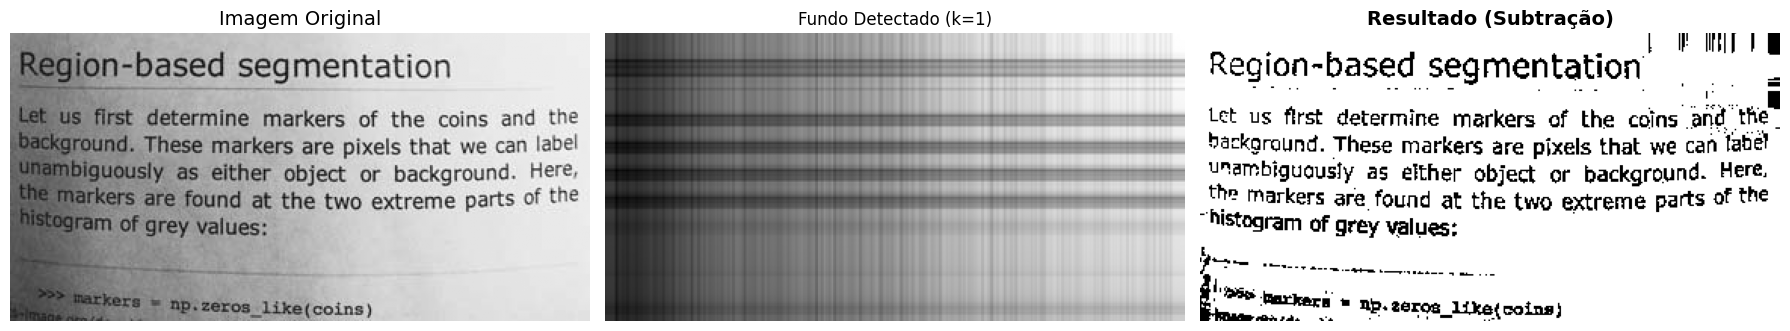

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from scipy.linalg import svd

# Carrega imagem de exemplo interna (texto escaneado)
image_matrix = data.page()

# Garante que a imagem esteja em escala de cinza
if image_matrix.ndim == 3:
    image_matrix = color.rgb2gray(image_matrix)

# Aplica a Decomposição de Valor Singular (SVD)
U, S, Vt = svd(image_matrix, full_matrices=False)

# Define k=1 para capturar apenas a estrutura principal (fundo)
k = 1

# Reconstrói a matriz do fundo (Aproximação de Baixo Posto)
Sigma_k = np.diag(S[:k])
U_k = U[:, :k]
Vt_k = Vt[:k, :]

background_estimated = np.dot(U_k, np.dot(Sigma_k, Vt_k))

# Subtrai a imagem original do fundo estimado para isolar o texto
foreground_text = background_estimated - image_matrix
foreground_text[foreground_text < 0] = 0 # Remove valores negativos
foreground_text = foreground_text / foreground_text.max() # Normaliza entre 0 e 1

# Aplica limiar para binarizar o resultado final
clean_scan = foreground_text > 0.1

# Visualização dos resultados
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("Imagem Original", fontsize=14)
plt.imshow(image_matrix, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"Fundo Detectado (k={k})", fontsize=12)
plt.imshow(background_estimated, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Resultado (Subtração)", fontsize=14, fontweight='bold')
plt.imshow(clean_scan, cmap='Greys')
plt.axis('off')

plt.tight_layout()
plt.show()